## ML Project (MID SEM)

We start by importing all the required libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Reading the dataset

In [2]:
df = pd.read_csv("StudentPerformanceFactors.csv")
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


### Basic Analysis of Dataset

In [ ]:
# data on all features
df.info()

In [ ]:
# statistics of all features
df.describe()

### Checking for null values

In [3]:
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

We can see that Teacher_Quality,Parental_Education_Level,Distance_from_Home columns have null values all are categorical columns so we will replace by mode

In [4]:
for col in df.columns:
    if df[col].dtype in ['int64', 'float64']: 
        mean_value = df[col].mean()
        df[col].fillna(mean_value, inplace=True)
    else: 
        mode_value = df[col].mode()[0]
        df[col].fillna(mode_value, inplace=True)
df.isnull().sum()

# df.dropna(inplace=True)

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64

In [ ]:
df.describe()

### Checking existence of duplicates:

In [5]:
df = df.drop_duplicates()
df.shape

(6607, 20)

In [ ]:
num_cols=[col for col in df.columns if df[col].dtype in ['int64', 'float64']]

### Outlier Detection and Removal

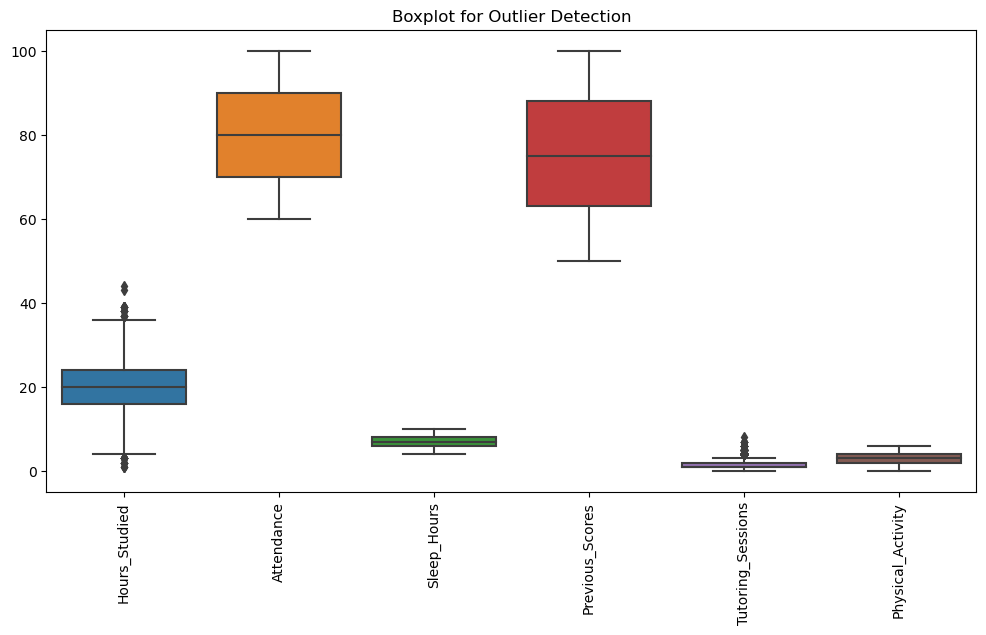

In [6]:
plt.figure(figsize=(12,6))
cols = [col for col in df.columns if df[col].dtype in ['int64', 'float64'] and col!='Exam_Score']
sns.boxplot(data=df[cols])
plt.xticks(rotation=90)
plt.title("Boxplot for Outlier Detection")
plt.show()

We notice a few outliers in the boxplot. Capping can be done to ensure the outliers do not affect the model.

In [ ]:
# Select numeric columns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols.remove('Exam_Score')  

# Capping outliers
for column in num_cols:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_cap = Q1 - 1.5 * IQR
    upper_cap = Q3 + 1.5 * IQR
    df[column] = np.where(df[column] < lower_cap, lower_cap, df[column])
    df[column] = np.where(df[column] > upper_cap, upper_cap, df[column])

print("\nSummary of numeric data after capping outliers:")
print(df[num_cols].describe())


In [ ]:
plt.figure(figsize=(12,6))
cols = [col for col in df.columns if df[col].dtype in ['int64', 'float64'] and col != 'Exam_Score']
sns.boxplot(data=df[cols])
plt.xticks(rotation=90)
plt.title("Boxplot for Outlier Detection")
plt.show()

### Exploratory Data Analysis

#### Univariate Analysis

#### Numerical Features

In [ ]:
colors = ['k', 'r', 'c', 'g']
num_cols = [col for col in df.columns if df[col].dtype in ['int64', 'float64'] and col not in ['Tutoring_Sessions','Physical_Activity','Sleep_Hours'] ]
plt.figure(figsize=(20, 25))
for i, col in enumerate(num_cols):
    plt.subplot(4, 3, i + 1)
    plt.title(' '.join(col.split('_')).title())
    sns.histplot(df[col], kde=True, color=colors[i % len(colors)])
plt.show()

In [ ]:
import math

colors = ['k', 'g', 'r', 'c']
cat_cols = ['Tutoring_Sessions','Physical_Activity','Sleep_Hours']
n_cols = 2 
n_rows = math.ceil(len(cat_cols) / n_cols) 

plt.figure(figsize=(15, n_rows * 5)) 

for i, col in enumerate(cat_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    plt.title(' '.join(col.split('_')).title())
    sns.countplot(x=df[col], color=colors[i % len(colors)])
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#### Categorical Features

In [ ]:
import math

colors = ['k', 'g', 'r', 'c']
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
n_cols = 2 
n_rows = math.ceil(len(cat_cols) / n_cols) 

plt.figure(figsize=(15, n_rows * 5)) 

for i, col in enumerate(cat_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    plt.title(' '.join(col.split('_')).title())
    sns.countplot(x=df[col], color=colors[i % len(colors)])
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

##### Distribution of classes of Target

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Exam_Score'], kde=True, color='skyblue', bins=20)
plt.title('Distribution of Exam Score')
plt.xlabel('Exam_Score')
plt.ylabel('Frequency')
plt.show()


#### Bivariate Analysis

#### Numerical Features

In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols.remove('Exam_Score')  # remove target

plt.figure(figsize=(15, len(num_cols)*4))

for i, col in enumerate(num_cols):
    plt.subplot(len(num_cols), 1, i + 1)
    sns.scatterplot(x=df[col], y=df['Exam_Score'])
    plt.title(f'{col} vs Exam Score')
    plt.xlabel(col)
    plt.ylabel('Exam Score')

plt.tight_layout()
plt.show()


#### Categorical Features

In [ ]:
palette = 'Set2'

n_cols = 1
n_rows = math.ceil(len(cat_cols) / n_cols)

plt.figure(figsize=(15, n_rows * 5))

for i, col in enumerate(cat_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.violinplot(x=col, y='Exam_Score', data=df, palette=palette)
    plt.title(" ".join(col.split('_')).title())
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [7]:
from sklearn.preprocessing import LabelEncoder
# ordinal_cols = ['Parental_Involvement', 'Motivation_Level', 'Teacher_Quality',
#                 'Parental_Education_Level', 'Family_Income', 'Distance_from_Home',
#                 'Peer_Influence']

# for col in ordinal_cols:
#     le = LabelEncoder()
#     df[col] = le.fit_transform(df[col])

# nominal_cols = ['Gender', 'School_Type', 'Learning_Disabilities',
#                 'Internet_Access', 'Extracurricular_Activities', 'Access_to_Resources']

# df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical Columns:", len(cat_cols))
num_cols = df.select_dtypes(include=['number']).columns.tolist()
print("Numerical Columns:", len(num_cols))
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

Categorical Columns: 13
Numerical Columns: 7


In [8]:

Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

ol_condition = ((df[num_cols] < (Q1 - 1.5 * IQR)) | (df[num_cols] > (Q3 + 1.5 * IQR)))
ol_iqr = ol_condition.any(axis=1)
print(f'No. of outliers: {np.sum(ol_iqr)}')

No. of outliers: 553


In [9]:
clean_data = df[~ol_iqr]

#### Multivariate Analysis

We plot the heatmap for the dataset to see the correlation between features

In [ ]:
plt.figure(figsize=(20,20))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

we are selecting all the features as maximum correlation is 0.58

In [10]:
# standardization
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
for col in num_cols:
    clean_data[col] = sc.fit_transform(clean_data[col].values.reshape(-1, 1))
clean_data.head()

C:\Users\kedik\AppData\Local\Temp\ipykernel_4076\738233289.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_data[col] = sc.fit_transform(clean_data[col].values.reshape(-1, 1))
C:\Users\kedik\AppData\Local\Temp\ipykernel_4076\738233289.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_data[col] = sc.fit_transform(clean_data[col].values.reshape(-1, 1))
C:\Users\kedik\AppData\Local\Temp\ipykernel_4076\738233289.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice fro

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,0.516070,0.350283,1,0,0,-0.023377,-0.147117,1,1,-1.314932,1,2,1,2,0.037064,0,1,2,1,0.005736
1,-0.176485,-1.389206,1,2,0,0.657031,-1.122403,1,1,0.718426,2,2,1,0,1.008430,0,0,1,0,-1.854632
2,0.689209,1.567925,2,2,1,-0.023377,1.106823,2,1,0.718426,2,2,1,1,1.008430,0,2,2,1,2.176166
3,1.554902,0.785155,1,2,1,0.657031,1.594466,2,1,-0.298253,2,2,1,0,1.008430,0,1,1,1,1.245982
4,-0.176485,1.046078,2,2,1,-0.703785,-0.704423,2,1,1.735105,2,0,1,1,1.008430,0,0,2,0,0.935920


## MODEL TRAINING

In [ ]:
X=df.drop('Exam_Score',axis=1)
y=df['Exam_Score']

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

X_train_r = X_train  
X_test_r = X_test

# Initialize and fit the model
rf_model = LinearRegression()
rf_model.fit(X_train_r, y_train)

# Predict on train and test sets
y_train_pred = rf_model.predict(X_train_r)
y_test_pred = rf_model.predict(X_test_r)

train_acc = r2_score(y_train, y_train_pred)
test_acc = r2_score(y_test, y_test_pred)

print(f"r2 score for train: {train_acc:.2f}")
print(f"r2 score for test: {test_acc:.2f}")
print(f"mse score for train: {mean_squared_error(y_train, y_train_pred):.2f}")
print(f"mse score for test: {mean_squared_error(y_test, y_test_pred):.2f}")

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(5)
X_train_poly=poly.fit_transform(X_train_r)
X_test_poly=poly.transform(X_test_r)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np


# Initialize and fit the model
rf_model = LinearRegression()
rf_model.fit(X_train_poly, y_train)

# Predict on train and test sets
y_train_pred = rf_model.predict(X_train_poly)
y_test_pred = rf_model.predict(X_test_poly)

train_acc = r2_score(y_train, y_train_pred)
test_acc = r2_score(y_test, y_test_pred)

print(f"r2 score for train: {train_acc:.2f}")
print(f"r2 score for test: {test_acc:.2f}")
print(f"mse score for train: {mean_squared_error(y_train, y_train_pred):.2f}")
print(f"mse score for test: {mean_squared_error(y_test, y_test_pred):.2f}")

In [ ]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
import numpy as np

# 1. Create a pipeline
# We can include a scaler in the pipeline (important for Ridge/Lasso)
pipeline = Pipeline([
    ('poly', PolynomialFeatures(include_bias=False)), # include_bias=False to prevent redundant intercept
    ('linear', LinearRegression()) # Or Ridge(random_state=42)
])

# 2. Define the grid of hyperparameters to search
param_grid = {
    'poly__degree': np.arange(1, 6),
}
# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='r2',          
    cv=5,                  
    verbose=1,
    n_jobs=-1
)

# Fit the grid search to your training data (X_train, y_train)
# The pipeline handles scaling internally
print("Starting Polynomial Regression hyperparameter tuning...")
grid_search.fit(X_train_r, y_train)

# Output the best parameters found
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best cross-validation R2 score: {grid_search.best_score_}")
best_poly_model = grid_search.best_estimator_

test_r2 = best_poly_model.score(X_test_r, y_test)
test_predictions = best_poly_model.predict(X_test_r)
test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))

print(f"Tuned Polynomial Regression Test R2: {test_r2}")
print(f"Tuned Polynomial Regression Test RMSE: {test_rmse}")

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

X_train_r = X_train  
X_test_r = X_test

# Initialize and fit the model
rf_model = Lasso()
rf_model.fit(X_train_r, y_train)

# Predict on train and test sets
y_train_pred = rf_model.predict(X_train_r)
y_test_pred = rf_model.predict(X_test_r)

train_acc = r2_score(y_train, y_train_pred)
test_acc = r2_score(y_test, y_test_pred)

print(f"r2 score for train: {train_acc:.2f}")
print(f"r2 score for test: {test_acc:.2f}")
print(f"mse score for train: {mean_squared_error(y_train, y_train_pred):.2f}")
print(f"mse score for test: {mean_squared_error(y_test, y_test_pred):.2f}")

In [ ]:
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred = ridge.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error for test:", mse)
print("R² Score for test:", r2)

In [ ]:

from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

X_train_r = X_train  
X_test_r = X_test

# Initialize and fit the model
rf_model = DecisionTreeRegressor()
rf_model.fit(X_train_r, y_train)

# Predict on train and test sets
y_train_pred = rf_model.predict(X_train_r)
y_test_pred = rf_model.predict(X_test_r)

train_acc = r2_score(y_train, y_train_pred)
test_acc = r2_score(y_test, y_test_pred)

print(f"r2 score for train: {train_acc:.2f}")
print(f"r2 score for test: {test_acc:.2f}")
print(f"mse score for train: {mean_squared_error(y_train, y_train_pred):.2f}")
print(f"mse score for test: {mean_squared_error(y_test, y_test_pred):.2f}")

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeRegressor
import numpy as np

# Define the range of parameters to search
param_dist = {
    'max_depth': [None] + list(np.arange(1, 20)), # Try depths from 1 to 20 or unlimited
    'min_samples_split': np.arange(2, 50),       # Min samples required to split a node
    'min_samples_leaf': np.arange(1, 25),        # Min samples required at a leaf node
    'max_features': ['auto', 'sqrt', 'log2', None] # Number of features to consider for best split
}
# Initialize the regressor
dt = DecisionTreeRegressor(random_state=42)

# Initialize RandomizedSearchCV
# n_iter = number of random combinations to try (start with 50 or 100)
# cv = number of cross-validation folds
# scoring = metric to optimize (e.g., 'neg_mean_squared_error' or 'r2')
random_search = RandomizedSearchCV(
    estimator=dt,
    param_distributions=param_dist,
    n_iter=50, 
    cv=5,
    scoring='r2', # Use R2 for a clear comparison
    verbose=1,
    random_state=42,
    n_jobs=-1 # Use all available processors
)

# Fit the random search to your training data
random_search.fit(X_train_r, y_train)

# Get the best parameters and the best score
print(f"Best parameters found: {random_search.best_params_}")
print(f"Best cross-validation R2 score: {random_search.best_score_}")
best_dt_model = random_search.best_estimator_
train_r2 = best_dt_model.score(X_train_r, y_train)
test_r2 = best_dt_model.score(X_test_r, y_test)

print(f"Tuned Model Train R2: {train_r2}")
print(f"Tuned Model Test R2: {test_r2}")

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Initialize and fit the model
rf_model = RandomForestRegressor()
rf_model.fit(X_train, y_train)

# Predict on train and test sets
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

train_acc = r2_score(y_train, y_train_pred)
test_acc = r2_score(y_test, y_test_pred)

print(f"r2 score for train: {train_acc:.2f}")
print(f"r2 score for test: {test_acc:.2f}")
print(f"mse score for train: {mean_squared_error(y_train, y_train_pred):.2f}")
print(f"mse score for test: {mean_squared_error(y_test, y_test_pred):.2f}")

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# Define the range of parameters to search
rf_param_dist = {
    'n_estimators': np.arange(50, 500, 50),          # Number of trees in the forest
    'max_depth': [None] + list(np.arange(3, 15)),    # Max depth of each tree (control overfitting)
    'min_samples_split': np.arange(2, 20),           # Min samples required to split a node
    'min_samples_leaf': np.arange(1, 10),            # Min samples required at a leaf node
    'max_features': ['sqrt', 'log2', 1.0],           # Number of features to consider for best split
    'bootstrap': [True, False]                       # Method to draw samples for each tree
}
# Initialize the regressor
# Initialize the Random Forest Regressor
rf = RandomForestRegressor(random_state=42)

# Initialize RandomizedSearchCV
rf_random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_param_dist,
    n_iter=100,             # Number of random combinations to try (adjust based on compute power)
    cv=5,                   # 5-fold cross-validation
    scoring='r2',           # Optimize for R-squared score
    verbose=1,
    random_state=42,
    n_jobs=-1               # Use all available processors
)

# Fit the random search to your training data (X_train, y_train)
print("Starting Random Search for Random Forest...")
rf_random_search.fit(X_train_r, y_train)

# Output the best parameters found
print(f"Best RF parameters found: {rf_random_search.best_params_}")
print(f"Best RF cross-validation R2 score: {rf_random_search.best_score_}")
best_rf_model = rf_random_search.best_estimator_

train_r2 = best_rf_model.score(X_train_r, y_train)
test_r2 = best_rf_model.score(X_test_r, y_test)

from sklearn.metrics import mean_squared_error
test_predictions = best_rf_model.predict(X_test_r)
test_rmse = mean_squared_error(y_test, test_predictions, squared=False)

print(f"Tuned Random Forest Train R2: {train_r2}")
print(f"Tuned Random Forest Test R2: {test_r2}")
print(f"Tuned Random Forest Test RMSE: {test_rmse}")

In [17]:
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

X_train_r = X_train  
X_test_r = X_test

# Initialize and fit the model
rf_model = SVR()
rf_model.fit(X_train_r, y_train)

# Predict on train and test sets
y_train_pred = rf_model.predict(X_train_r)
y_test_pred = rf_model.predict(X_test_r)

train_acc = r2_score(y_train, y_train_pred)
test_acc = r2_score(y_test, y_test_pred)

print(f"r2 score for train: {train_acc:.2f}")
print(f"r2 score for test: {test_acc:.2f}")
print(f"mse score for train: {mean_squared_error(y_train, y_train_pred):.2f}")
print(f"mse score for test: {mean_squared_error(y_test, y_test_pred):.2f}")

r2 score for train: 0.99
r2 score for test: 0.98
mse score for train: 0.01
mse score for test: 0.02


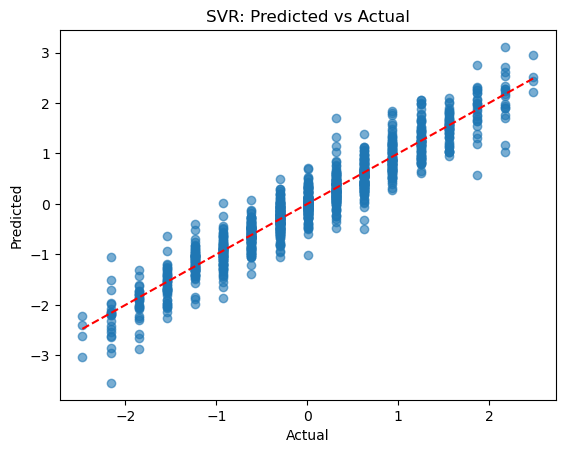

In [24]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_test_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("SVR: Predicted vs Actual")
plt.show()


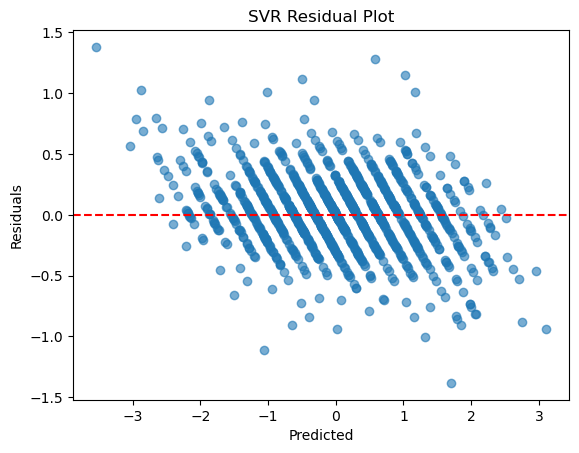

In [23]:
residuals = y_test - y_test_pred
plt.scatter(y_test_pred, residuals, alpha=0.6)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("SVR Residual Plot")
plt.show()


R² (Train): 0.993
R² (Test):  0.971
MSE (Train): 0.007
MSE (Test):  0.028


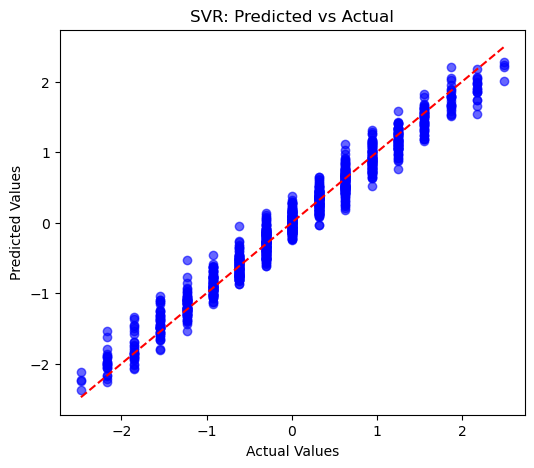

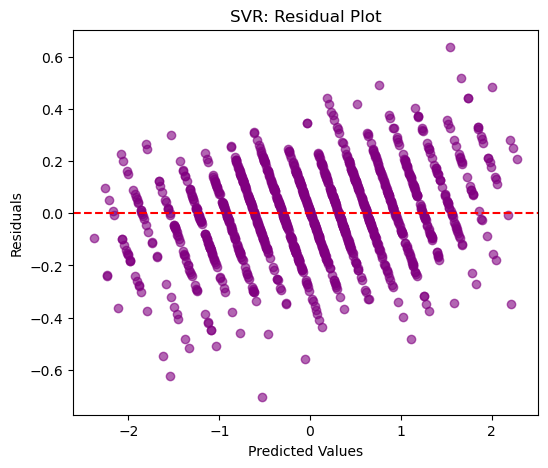

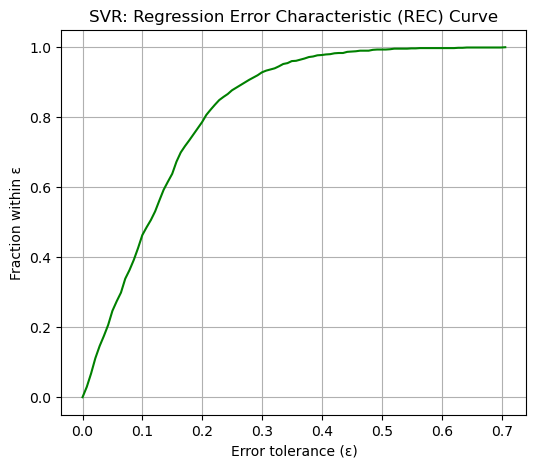

In [26]:
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# --- Train your SVR model ---
X_train_r = X_train  
X_test_r = X_test

rf_model = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)
rf_model.fit(X_train_r, y_train)

# --- Predictions ---
y_train_pred = rf_model.predict(X_train_r)
y_test_pred = rf_model.predict(X_test_r)

# --- Metrics ---
train_acc = r2_score(y_train, y_train_pred)
test_acc = r2_score(y_test, y_test_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

print(f"R² (Train): {train_acc:.3f}")
print(f"R² (Test):  {test_acc:.3f}")
print(f"MSE (Train): {train_mse:.3f}")
print(f"MSE (Test):  {test_mse:.3f}")

# =====================================================
# 🧠 1. Predicted vs Actual
# =====================================================
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_test_pred, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("SVR: Predicted vs Actual")
plt.show()

# =====================================================
# 📉 2. Residual Plot
# =====================================================
residuals = y_test - y_test_pred
plt.figure(figsize=(6,5))
plt.scatter(y_test_pred, residuals, alpha=0.6, color='purple')
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("SVR: Residual Plot")
plt.show()

# =====================================================
# ⚪ 3. Support Vectors (works best if X is 1D)
# =====================================================
if X_train_r.shape[1] == 1:
    X_plot = np.sort(X_train_r, axis=0)
    y_plot = rf_model.predict(X_plot)

    plt.figure(figsize=(7,5))
    plt.scatter(X_train_r, y_train, color='lightblue', label='Training data')
    plt.plot(X_plot, y_plot, color='red', label='SVR Fit')
    plt.scatter(X_train_r[rf_model.support_], y_train[rf_model.support_],
                facecolors='none', edgecolors='k', label='Support Vectors')
    plt.plot(X_plot, y_plot + rf_model.epsilon, 'k--', label='+ε Tube')
    plt.plot(X_plot, y_plot - rf_model.epsilon, 'k--', label='-ε Tube')
    plt.xlabel("Feature")
    plt.ylabel("Target")
    plt.title("SVR Fit and ε-Tube")
    plt.legend()
    plt.show()

# =====================================================
# 📈 4. REC Curve (Regression Error Characteristic)
# =====================================================
errors = np.abs(y_test - y_test_pred)
epsilons = np.linspace(0, max(errors), 100)
fraction_within = [np.mean(errors <= e) for e in epsilons]

plt.figure(figsize=(6,5))
plt.plot(epsilons, fraction_within, color='green')
plt.xlabel("Error tolerance (ε)")
plt.ylabel("Fraction within ε")
plt.title("SVR: Regression Error Characteristic (REC) Curve")
plt.grid(True)
plt.show()


Feature importance ranking:
Attendance: 0.9938
Hours_Studied: 0.5450
Previous_Scores: 0.0938
Parental_Involvement: 0.0828
Access_to_Resources: 0.0816
Tutoring_Sessions: 0.0454
Parental_Education_Level: 0.0298
Peer_Influence: 0.0266
Family_Income: 0.0241
Motivation_Level: 0.0215
Distance_from_Home: 0.0193
Learning_Disabilities: 0.0171
Teacher_Quality: 0.0145
Internet_Access: 0.0127
Physical_Activity: 0.0121
Extracurricular_Activities: 0.0113
Sleep_Hours: 0.0012
School_Type: -0.0002
Gender: -0.0003


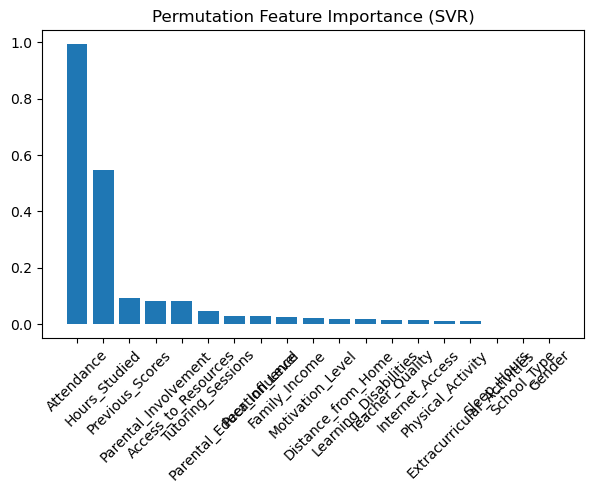

In [27]:
from sklearn.inspection import permutation_importance

result = permutation_importance(rf_model, X_test_r, y_test, scoring='r2', n_repeats=10, random_state=42)

importances = result.importances_mean
indices = np.argsort(importances)[::-1]

print("Feature importance ranking:")
for i in indices:
    print(f"{X_train.columns[i]}: {importances[i]:.4f}")

# Plot
plt.figure(figsize=(7,4))
plt.bar(range(len(importances)), importances[indices], align='center')
plt.xticks(range(len(importances)), X_train.columns[indices], rotation=45)
plt.title("Permutation Feature Importance (SVR)")
plt.show()


In [ ]:
from sklearn.svm import SVR
from sklearn.model_selection import RandomizedSearchCV
import numpy as np
from scipy.stats import reciprocal, uniform

# Define the range of parameters to search
svr_param_dist = {
    'kernel': ['rbf'],  # RBF is highly effective for most problems
    'C': reciprocal(0.1, 1000),  # A continuous range is better for C
    'gamma': reciprocal(0.001, 1), # A continuous range for gamma as well
    'epsilon': uniform(0.01, 1)    # Controls the width of the 'tube' around the fit
}
# Initialize the SVR regressor
svr = SVR()

# Initialize RandomizedSearchCV
svr_random_search = RandomizedSearchCV(
    estimator=svr,
    param_distributions=svr_param_dist,
    n_iter=50,             # Number of random combinations to try
    cv=5,                   # 5-fold cross-validation
    scoring='r2',           # Optimize for R-squared score
    verbose=1,
    random_state=42,
    n_jobs=-1               # Use all available processors
)

# Fit the random search to your *SCALED* training data (X_train_scaled, y_train)
# NOTE: Ensure your data is scaled before this step!
print("Starting Random Search for SVR...")
svr_random_search.fit(X_train_r, y_train) 

# Output the best parameters found
print(f"Best SVR parameters found: {svr_random_search.best_params_}")
print(f"Best SVR cross-validation R2 score: {svr_random_search.best_score_}")
best_svr_model = svr_random_search.best_estimator_

# Remember to use the scaled test data
train_r2 = best_svr_model.score(X_train_r, y_train)
test_r2 = best_svr_model.score(X_test_r, y_test)

from sklearn.metrics import mean_squared_error
test_predictions = best_svr_model.predict(X_test_r)
test_rmse = mean_squared_error(y_test, test_predictions, squared=False)

print(f"Tuned SVR Train R2: {train_r2}")
print(f"Tuned SVR Test R2: {test_r2}")
print(f"Tuned SVR Test RMSE: {test_rmse}")

In [18]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

X_train_r = X_train  
X_test_r = X_test

# Initialize and fit the model
rf_model = GradientBoostingRegressor()
rf_model.fit(X_train_r, y_train)

# Predict on train and test sets
y_train_pred = rf_model.predict(X_train_r)
y_test_pred = rf_model.predict(X_test_r)

train_acc = r2_score(y_train, y_train_pred)
test_acc = r2_score(y_test, y_test_pred)

print(f"r2 score for train: {train_acc:.2f}")
print(f"r2 score for test: {test_acc:.2f}")
print(f"mse score for train: {mean_squared_error(y_train, y_train_pred):.2f}")
print(f"mse score for test: {mean_squared_error(y_test, y_test_pred):.2f}")

r2 score for train: 0.96
r2 score for test: 0.93
mse score for train: 0.04
mse score for test: 0.06


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

gbr_param_dist = {
    'n_estimators': np.arange(100, 1000, 100),       # Number of boosting stages
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],    # Contribution of each tree
    'max_depth': np.arange(3, 8),                    # Depth of each individual tree
    'min_samples_split': np.arange(2, 20),           # Minimum samples required to split a node
    'min_samples_leaf': np.arange(1, 10),            # Minimum samples required at a leaf node
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],          # Fraction of samples for each tree (stochastic GB)
    'max_features': ['sqrt', 'log2', None]           # Number of features to consider at each split
}
# Initialize the base GBR regressor
gbr = GradientBoostingRegressor(random_state=42)

# Setup the search
gbr_random_search = RandomizedSearchCV(
    estimator=gbr,
    param_distributions=gbr_param_dist,
    n_iter=50,             # Number of combinations to try
    cv=5,                   # Use 5-fold cross-validation
    scoring='r2',           # Optimize for R-squared
    random_state=42,
    n_jobs=-1
)

print("Starting GradientBoostingRegressor hyperparameter tuning...")
gbr_random_search.fit(X_train_r, y_train)

print(f"Best GBR parameters found: {gbr_random_search.best_params_}")
print(f"Best GBR cross-validation R2 score: {gbr_random_search.best_score_}")
best_gbr_model = gbr_random_search.best_estimator_

test_predictions_tuned = best_gbr_model.predict(X_test_r)

tuned_r2 = r2_score(y_test, test_predictions_tuned)
tuned_rmse = np.sqrt(mean_squared_error(y_test, test_predictions_tuned))

print(f"Tuned GBR Test R2: {tuned_r2}")
print(f"Tuned GBR Test RMSE: {tuned_rmse}")